In [1]:
# Essential libraries
!pip install pandas numpy joblib matplotlib seaborn scikit-learn 

STARTING CUSTOMER CHURN PIPELINE

Data shape: (2800, 10)
Columns: ['user_id', 'signup_date', 'plan_type', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'churn']

Train: (2240, 9), Test: (560, 9)

Numeric features: ['user_id', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'account_age_days']
Categorical features: ['plan_type']

Test Metrics:
  ACCURACY: 0.6786
  PRECISION: 0.7043
  RECALL: 0.7570
  F1: 0.7297
  ROC_AUC: 0.7302

Confusion Matrix:
[[137 102]
 [ 78 243]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.57      0.60       239
           1       0.70      0.76      0.73       321

    accuracy                           0.68       560
   macro avg       0.67      0.67      0.67       560
weighted avg       0.68      0.68      0.68       560


Top 10 Important Features:
a

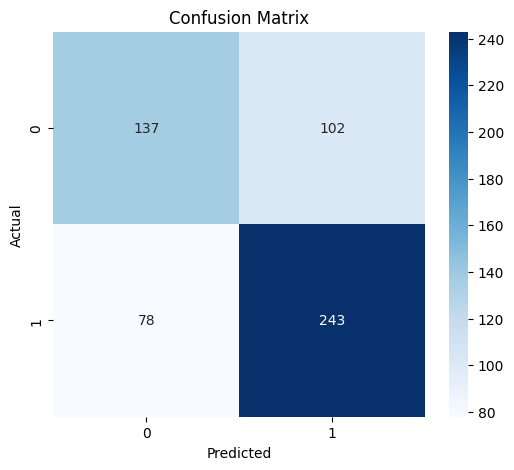

In [4]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# ============= Configuration ===============

class Config:
    # Data setting
    DATA_PATH = 'customer_subscription_churn_usage_patterns.csv'
    TARGET_COL = 'churn'
    TEST_SIZE = 0.2
    RANDOM_STATE = 42

    # Model Setting
    MODEL_TYPE = "RandomForest"  # Options: RandomForest / LogisticRegression
    USE_GRID_SEARCH = False

    # Feature settings (adjust based on your data)
    EXCLUDE_COLS = []       # Columns to exclude (like IDs, dates)
    CATEGORICAL_COLS = []   # Will auto-detect if empty 

    # Paths for saving
    MODEL_SAVE_PATH = "models/best_model.pkl"
    METRICS_SAVE_PATH = "models/metrics.json"

# ============= Pipeline Function ===================

def run_ml_pipeline(config: Config):
    print("="*60)
    print("STARTING CUSTOMER CHURN PIPELINE")
    print("="*60)

    # --------- 1. Load Data -----------
    df = pd.read_csv(config.DATA_PATH)
    print(f"\nData shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

    # --------- 2. Preprocess Data -----------
    df = df.copy()

    # Convert signup_date
    if "signup_date" in df.columns:
        df["signup_date"] = pd.to_datetime(df["signup_date"], dayfirst=True)
        df["account_age_days"] = (pd.Timestamp.today() - df["signup_date"]).dt.days
        df = df.drop(columns=["signup_date"])

    # Drop excluded/leakage columns
    df = df.drop(columns=config.EXCLUDE_COLS, errors="ignore")

    # Encode target
    df[config.TARGET_COL] = df[config.TARGET_COL].map({"Yes": 1, "No": 0})

    # ----------- 3. Features & Target -------------
    if config.TARGET_COL not in df.columns:
        raise ValueError(f'Target column "{config.TARGET_COL}" not found!')

    X = df.drop(columns=[config.TARGET_COL])
    y = df[config.TARGET_COL]

    # -------- 4. Train-Test Split -----------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=config.TEST_SIZE,
        stratify=y,
        random_state=config.RANDOM_STATE
    )
    print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

    # ----------- 5. Feature Identification -----------
    if not config.CATEGORICAL_COLS:
        categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    else:
        categorical_cols = config.CATEGORICAL_COLS

    numeric_cols = [c for c in X_train.select_dtypes(include=["int64", "float64"]).columns
                    if c not in categorical_cols]

    print(f"\nNumeric features: {numeric_cols}")
    print(f"Categorical features: {categorical_cols}")

    # ------------ 6. Preprocessing Pipeline -------------
    numeric_pipeline = Pipeline([
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    # ----------- 7. Model Selection ----------------
    if config.MODEL_TYPE == "RandomForest":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=config.RANDOM_STATE
        )
        param_grid = {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10]
        }
    elif config.MODEL_TYPE == "LogisticRegression":
        model = LogisticRegression(max_iter=1000)
        param_grid = {
            "model__C": [0.01, 0.1, 1, 10]
        }
    else:
        raise ValueError(f'Model "{config.MODEL_TYPE}" not supported')

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # --------------- 8. Train Model -----------
    if config.USE_GRID_SEARCH:
        cv = KFold(n_splits=5, shuffle=True, random_state=config.RANDOM_STATE)
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"\nBest parameters: {grid_search.best_params_}")
        print(f"Best CV score: {grid_search.best_score_:.4f}")
    else:
        pipeline.fit(X_train, y_train)
        best_model = pipeline

    # --------------- 9. Evaluate Model ------------
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    print("\nTest Metrics:")
    for k, v in metrics.items():
        print(f"  {k.upper()}: {v:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ------------- 10. Feature Importance -------------
    if hasattr(best_model.named_steps["model"], "feature_importances_"):
        rf = best_model.named_steps["model"]

        cat_features = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(
            categorical_cols
        )
        feature_names = np.concatenate([numeric_cols, cat_features])
        importances = rf.feature_importances_
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

        print("\nTop 10 Important Features:")
        print(feat_imp.head(10))

    # ----------- 11. Save Artifacts -----------
    Path("models").mkdir(exist_ok=True)
    joblib.dump(best_model, config.MODEL_SAVE_PATH)
    with open(config.METRICS_SAVE_PATH, "w") as f:
        json.dump(metrics, f, indent=2)
    print("\nArtifacts saved successfully.")

    print("\nPIPELINE COMPLETED SUCCESSFULLY!\n")

    return {
        "model": best_model,
        "metrics": metrics,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "feature_names": {
            "numeric": numeric_cols,
            "categorical": categorical_cols
        }
    }


# ============= VISUALIZATION FUNCTION ===============
def plot_results(result):
    import matplotlib.pyplot as plt
    import seaborn as sns

    y_test, y_pred = result["y_test"], result["y_pred"]

    # Confusion matrix heatmap
    plt.figure(figsize=(6,5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ============ MAIN ================
if __name__ == "__main__":
    result = run_ml_pipeline(Config)
    plot_results(result)